In [ ]:
import os
import copy
import json
import time
from pathlib import Path
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from dateutil.relativedelta import relativedelta
import sys
sys.path.append("../src")
from dateutil.relativedelta import relativedelta

from Models.model import GLSTMBatch
from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import *
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     #haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor
                                     )     
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss
from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "custom"  # quick or full
if RUN_MODE == "full":
    start_date = "2000-01-01"
    end_date   = "2025-12-31"

elif RUN_MODE == "custom":
    start_date = "2010-01-01"
    end_date   = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date   = "2025-12-31"

eps          = 1e-6
window_size  = 30
horizon      = 5
criterion_km = 120
lstm_layers  = 1
dropout      = 0.3
K            = 6
batch_size   = 64
num_workers  = 0
vertex_idx   = 32
weight_decay = 5e-4
test_lstm    = False
learn_adj    = True
loss_fn = nn.MSELoss()
topology     = 'knn'  # 'knn' ou 'distance'

catalog_dir = Path("..") / "Datasets" / "dados_inmet"
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)



N = len(estacoes_RS)
if topology =='knn':
    edge_index, pos = knn_topology(estacoes_RS, k=K)
else:
    edge_index, edge_weights, pos = distance_graph(estacoes_RS, criterion_km)

In [ ]:
# Carregamento dos arquivos NetCDF (Datasets)
dataset_load_time = time.time()
rea_tp   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))
rea_vv   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "vv_94-25.nc")).sel(time=slice(start_date, end_date))
rea_temp = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "temp_99-25.nc")).sel(time=slice(start_date, end_date))
rea_sh   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc")).sel(time=slice(start_date, end_date))
rea_wind = xr.open_dataset(r"C:\CLimate Change Project\Utils\wind_data\era5_wind_14-25.nc").sel(time=slice(start_date, end_date))
print("Done loading datasets in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
print("Done loading vv in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
temp_daily_dataset = daily_temp_features(rea_temp)
print("Done loading temp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))
print("Done loading tp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
print("Dataset com", temp_daily_dataset.time.values.shape[0], "dias disponíveis.")

In [11]:
# Data loading and feature construction

#TENSOR X COM TODAS COVARIAVEIS E DADOS NO FORMATO [T,N,F]

T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1



rea_tp = xr.open_dataset(r"C:\Climate Change Project\Datasets\.nc files\era5_precipitation_80-26.nc")
rea_vv = xr.open_dataset(r"C:\Climate Change Project\Utils\vertical_velocity_data\era5_vv_06-25.nc")
rea_temp = xr.open_dataset(r"C:\Climate Change Project\Utils\temperature_data\temp_05-25.nc")
vv_dataset = daily_vertical_velocity(rea_vv, var_name="w")
temp_dataset = daily_temp_features(rea_temp)
#rea_wind = xr.open_dataset(r"C:\CLimate Change Project\Utils\wind_data\era5_wind_14-25.nc")
#wind_daily = daily_wind_uv_features(rea_wind, u_var='u', v_var='v', levels=(500, 850))



X_tp = tensor_data_precip(rea_tp, t1=start_date, t2=end_date, stations=estacoes_RS).reshape(T, N, 1)
X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)
X_temp = get_temp(start_date, end_date, temp_dataset, stations=estacoes_RS).reshape(T, N, -1)
X_vv = get_vv(start_date, end_date, vv_dataset, estacoes_RS).reshape(T, N, -1)

X_sh = era5_specific_humidity_tensor(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc"), estacoes_RS, start=start_date, end=end_date, var_name="q")



c:\Local Reposity\LSTM-GNN\Notebooks\../src\Data\feature_extraction.py:463: FutureWarning: updating coordinate 'datetime', which is a PandasMultiIndex, would leave the multi-index level coordinates ['time', 'step'] in an inconsistent state. This will raise an error in the future. Use `.drop_vars(['datetime', 'time', 'step'])` to drop the coordinates' values before assigning new coordinate values.
  tp = tp.assign_coords(datetime=tp.valid_time.data)


In [24]:
X = torch.cat([X_tp,  X_year, X_temp, X_vv, X_sh], dim=-1)

X = X[365 * 12:]

In [25]:
#SEPARAÇÃO EM TRAIN/VALIDATION/TEST
eps = 1e-6
window_size = 30
horizon     = 1


Xs, ys = create_sliding_windows(X, X[...,0], window_size=window_size, horizon=horizon)

ys = ys.clamp_min(eps)
Xs[...,0] = Xs[...,0].clamp_min(eps)

num_samples = Xs.shape[0]

In [26]:
from sklearn.preprocessing import StandardScaler

X_train, y_train, X_val, y_val, X_test, y_test = train_split(Xs, ys)


target_mean, target_std = fit_log1p_zscore_stats(X_train, y_train, target_col=0)

X_train[..., 0] = apply_log1p_zscore(X_train[..., 0], target_mean, target_std)
X_val[..., 0] = apply_log1p_zscore(X_val[..., 0], target_mean, target_std)
X_test[..., 0] = apply_log1p_zscore(X_test[..., 0], target_mean, target_std)

y_train = apply_log1p_zscore(y_train, target_mean, target_std)
y_val = apply_log1p_zscore(y_val, target_mean, target_std)
y_test = apply_log1p_zscore(y_test, target_mean, target_std)


# padroniza apenas features exogenas (colunas 2:)
X_train[..., 2:], scalers = normalize_features(X_train[..., 2:], scaler=StandardScaler)

for i, sc in enumerate(scalers):
    X_val[..., 2 + i] = torch.tensor(
        sc.transform(X_val[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 2 + i].shape)
    X_test[..., 2 + i] = torch.tensor(
        sc.transform(X_test[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 2 + i].shape)

#normalization_stats = {
#    "target_mean": float(target_mean),
#    "target_std": float(target_std),
#}
#print("normalization_stats:", normalization_stats)

# Train/val split and DataLoaders

train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=batch_size, device=device)

print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

train batches: 126 val batches: 36 test batches: 19


In [14]:
def grad_global_norm(model):
    total_sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            g = p.grad.detach()
            total_sq += g.pow(2).sum().item()
    return total_sq ** 0.5

def weighted_mse_loss(
    y_pred,
    y_true,
    extreme_quantile=0.9,
    extreme_weight=10.0,
    is_log=False,
    eps=1e-6
):
    """
    Weighted MSE loss that emphasizes extreme rainfall, compatible with both
    log-transformed and raw targets.

    Args:
        y_pred: torch.Tensor, model predictions
        y_true: torch.Tensor, true values
        extreme_quantile: float, quantile to define "extreme rainfall" (default 0.9)
        extreme_weight: float, weight multiplier for extreme rainfall (default 5.0)
        is_log: bool, whether y_true (and y_pred) are log-transformed (default True)
        eps: small number to prevent log(0)
    """
    # Compute threshold in original scale
    if is_log:
        y_true_orig = torch.expm1(y_true)
        y_pred_orig = torch.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    threshold = torch.quantile(y_true_orig, extreme_quantile)

    # Create weights: extreme rainfall gets high weight
    weights = torch.ones_like(y_true)
    weights[y_true_orig > threshold] = extreme_weight

    # Weighted MSE (compute on original scale if is_log)
    if is_log:
        # compute loss in log space (optional: can use pred vs true in log)
        loss = torch.mean(weights * (y_pred - y_true) ** 2)
    else:
        loss = torch.mean(weights * (y_pred - y_true) ** 2)

    return loss

In [15]:
# Graph + model
from torch_geometric.nn.conv import GCNConv, ChebConv

class GLSTMCellBatch(nn.Module):
    def __init__(self, N, input_size, hidden_size, edge_index, edge_weight=None, learn_adj=True, test_lstm=True):
        super().__init__()
        self.edge_index = edge_index
        self.learn_adj = learn_adj
        
        
        if edge_weight is None:
            self.edge_weight = None if not learn_adj else torch.ones(edge_index.shape[1], device=edge_index.device)
        else:
            self.edge_weight = edge_weight.to(edge_index.device) if torch.is_tensor(edge_weight) else torch.tensor(edge_weight, device=edge_index.device)

        #A_init = adjacency_matrix(N, edge_index, self.edge_weight)
        #if learn_adj:
        #    self.A = nn.Parameter(A_init)
        #else:
        #    self.register_buffer("A", A_init)
            
        """
        else:
            self.gcn_h = GCNConv(hidden_size, hidden_size)
            self.gcn_c = GCNConv(hidden_size, hidden_size)
        """
        if test_lstm==True:
            self.A = torch.eye(N, device=edge_index.device)
        
        self.W_i = nn.Linear(input_size, hidden_size).to(device)
        self.W_f = nn.Linear(input_size, hidden_size).to(device)
        self.W_o = nn.Linear(input_size, hidden_size).to(device)
        self.W_u = nn.Linear(input_size, hidden_size).to(device)

        self.U_i = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_f = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_o = nn.Linear(hidden_size, hidden_size).to(device)
        self.U_u = nn.Linear(hidden_size, hidden_size).to(device)

    def forward(self, X, H_prev, C_prev):
        # X: [B, N, F], H/C: [B, H, N]
        T, N, F = X.shape
        if self.learn_adj:
            

                    
            H_graph = torch.einsum("bhm,mn->bhn", H_prev, self.A).to(device)
            C_graph = torch.einsum("bhm,mn->bhn", C_prev, self.A).to(device)


            Hg = H_graph.permute(0, 2, 1).to(device)
            Hp = H_prev.permute(0, 2, 1).to(device)
        else:
            A_eff = self.A
            
            H_graph = torch.einsum("bhm,mn->bhn", H_prev, A_eff).to(device)
            C_graph = torch.einsum("bhm,mn->bhn", C_prev, A_eff).to(device)


            Hg = H_graph.permute(0, 2, 1).to(device)
            Hp = H_prev.permute(0, 2, 1).to(device)
            
       
        Xp = X.to(device)

        I = torch.sigmoid(self.W_i(Xp) + self.U_i(Hg)).permute(0, 2, 1)
        Fg = torch.sigmoid(self.W_f(Xp) + self.U_f(Hp)).permute(0, 2, 1)
        O = torch.sigmoid(self.W_o(Xp) + self.U_o(Hg)).permute(0, 2, 1)
        U = torch.tanh(self.W_u(Xp) + self.U_u(Hg)).permute(0, 2, 1)

        C_t = I * U + Fg * C_graph
        H_t = O * torch.tanh(C_t)
        return C_t, H_t


class GLSTMBatch(nn.Module):
    def __init__(self, N, edge_index, in_channels, hidden_size, out_channels=horizon, lstm_layers=1, learn_adj=True):
        super().__init__()
        self.N = N
        self.lstm_layers = lstm_layers
        self.hidden_size = hidden_size
        self.window = out_channels
        self.cell_0 = GLSTMCellBatch(N, in_channels, hidden_size, edge_index, learn_adj=learn_adj)
        self.cells = nn.ModuleList([GLSTMCellBatch(N=N, input_size=hidden_size, hidden_size=hidden_size,edge_index=edge_index, learn_adj=learn_adj) for _ in range(self.lstm_layers-1)])
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_size, out_channels)
        ).to(device)
        

    def forward(self, x_seq):
        # x_seq: [B, T, N, F]
        
        B, T, N, _ = x_seq.shape

        H = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
        C = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
        
        
        H_layers = torch.zeros((B, T, self.N, self.hidden_size), device=x_seq.device, dtype=x_seq.dtype)
        
        
        for t in range(T):
            C, H = self.cell_0(x_seq[:,t], H, C)
            H_layers[:,t] = H.permute(0,2,1)
        
        #print(H_layers[:,t].shape)
        
        for j in range(self.lstm_layers-1):
                H = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
                C = torch.zeros((B, self.hidden_size, self.N), device=x_seq.device)
                for t in range(T):
                    #print(j,t)
                    C, H = self.cells[j](H_layers[:,t], H, C)
                    H_layers[:,t] = H.permute(0,2,1)
        out = H_layers[:,-1].to(device)

        return self.fc(out).permute(0,2,1)   # [B, OUT, N]

In [20]:
# Training routines (no benchmark)

def eval_with_loader(model, loader, criterion, use_amp, amp_device, amp_dtype):
    model.eval()
    total_loss, total_mse, total_mae, total_mape, total_r2 = 0.0, 0.0, 0.0, 0.0, 0.0
    steps = 0
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            assert_finite(f"eval_xb_batch{batch_idx}", xb)
            assert_finite(f"eval_yb_batch{batch_idx}", yb)

            with torch.autocast(device_type=amp_device, dtype=amp_dtype, enabled=use_amp):
                pred = model(xb)
                assert_finite(f"eval_pred_batch{batch_idx}", pred)
                loss = criterion(pred, yb)

            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite eval loss on batch={batch_idx}")

            total_loss += loss.item()
            total_mse += mse_fn(pred, yb).item()
            total_mae += mae_fn(pred, yb).item()
            total_mape += safe_mape(yb, pred, eps=1e-3).item()
            total_r2 += safe_r2(yb.reshape(-1), pred.reshape(-1)).item()
            steps += 1

    return {
        "loss": total_loss / max(steps, 1),
        "mse": total_mse / max(steps, 1),
        "mae": total_mae / max(steps, 1),
        "mape": total_mape / max(steps, 1),
        "r2": total_r2 / max(steps, 1),
    }


def train_batched_only(
    model,
    train_loader,
    val_loader,
    train_period,
    hidden_dim,
    epochs,
    lr,
    weight_decay,
    patience,
    run_dir=None,
    criterion=None,
    clip_grad_norm=1.0,
):
    model = copy.deepcopy(model).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if criterion is None:
        criterion = nn.MSELoss()

    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()

    use_amp = False
    amp_device = "cuda" if device == "cuda" else "cpu"
    amp_dtype = torch.float16 if device == "cuda" else torch.bfloat16
    scaler = torch.amp.GradScaler("cuda", enabled=(use_amp and device == "cuda"))
    print(f"train_batched_only: use_amp={use_amp} criterion={criterion.__class__.__name__}")

    best_model = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    counter = 0

    history = {
        "train_loss": [], "train_mse": [], "train_mae": [], "train_mape": [], "train_r2": [],
        "val_loss": [], "val_mse": [], "val_mae": [], "val_mape": [], "val_r2": [], "epoch_time": [],
        "grad_norm_before": [],
    }

    for ep in range(epochs):
        t0 = time.perf_counter()
        model.train()
        train_loss = 0.0
        train_mse = 0.0
        train_mae = 0.0
        train_mape = 0.0
        train_r2 = 0.0
        grad_norm_acc = 0.0
        steps = 0

        for batch_idx, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            assert_finite(f"train_xb_epoch{ep}_batch{batch_idx}", xb)
            assert_finite(f"train_yb_epoch{ep}_batch{batch_idx}", yb)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=amp_device, dtype=amp_dtype, enabled=use_amp):
                pred = model(xb)
                assert_finite(f"train_pred_epoch{ep}_batch{batch_idx}", pred)
                loss = criterion(pred, yb)

            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite loss epoch={ep} batch={batch_idx}")

            if use_amp:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            for name, param in model.named_parameters():
                if param.grad is not None and (not torch.isfinite(param.grad).all()):
                    raise RuntimeError(f"non-finite gradient in {name} epoch={ep} batch={batch_idx}")

            gn_before = grad_global_norm(model)
            grad_norm_acc += gn_before

            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

            if use_amp:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            train_loss += loss.item()
            train_mse += mse_fn(pred, yb).item()
            train_mae += mae_fn(pred, yb).item()
            train_mape += safe_mape(yb, pred, eps=1e-3).item()
            train_r2 += safe_r2(yb.reshape(-1), pred.reshape(-1)).item()
            steps += 1

        history["train_loss"].append(train_loss / max(steps, 1))
        history["train_mse"].append(train_mse / max(steps, 1))
        history["train_mae"].append(train_mae / max(steps, 1))
        history["train_mape"].append(train_mape / max(steps, 1))
        history["train_r2"].append(train_r2 / max(steps, 1))
        history["grad_norm_before"].append(grad_norm_acc / max(steps, 1))

        val_metrics = eval_with_loader(model, val_loader, criterion, use_amp, amp_device, amp_dtype)
        history["val_loss"].append(val_metrics["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_mape"].append(val_metrics["mape"])
        history["val_r2"].append(val_metrics["r2"])

        history["epoch_time"].append(time.perf_counter() - t0)

        print(
            f"epoch={ep+1}/{epochs} "
            f"train_loss={history['train_loss'][-1]:e} / "
            f"val_loss={history['val_loss'][-1]:e} / "
            f"train_mae={history['train_mae'][-1]:e} / "
            f"val_mae={history['val_mae'][-1]:e} / "
            f"val_mape={history['val_mape'][-1]:e} / "
            f"val_r2={history['val_r2'][-1]:e}"
        )

        if history["val_loss"][-1] < best_val_loss:
            best_val_loss = history["val_loss"][-1]
            counter = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            counter += 1

        if counter >= patience:
            model.load_state_dict(best_model)
            print("Early Stopping")
            break

    model.load_state_dict(best_model)

    summary = {
        "hiddem_dim": hidden_dim,
        "train_period": train_period,
        "device": device,
        "epochs_requested": epochs,
        "epochs_ran": len(history["epoch_time"]),
        "lr": lr,
        "weight_decay": weight_decay,
        "patience": patience,
        "batch_size": train_loader.batch_size,
        "criterion": criterion.__class__.__name__,
        "best_val_loss": best_val_loss,
        "last_val_mse": history["val_mse"][-1] if history["val_mse"] else None,
        "last_val_mae": history["val_mae"][-1] if history["val_mae"] else None,
        "last_val_mape": history["val_mape"][-1] if history["val_mape"] else None,
        "last_val_r2": history["val_r2"][-1] if history["val_r2"] else None,
        "total_time_s": float(sum(history["epoch_time"])),
    }

    if run_dir is not None:
        run_dir = Path(run_dir)
        run_dir.mkdir(parents=True, exist_ok=True)

        save_error_plots(
            str(run_dir),
            history["train_mse"], history["val_mse"],
            history["train_mae"], history["val_mae"],
            history["train_r2"], history["val_r2"],
        )

        torch.save(history, run_dir / "hist.pt")
        torch.save(model.state_dict(), run_dir / "model_state_dict.pt")
        with open(run_dir / "run_summary.json", "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2)

    return model, history, summary

In [17]:
#funções de plots necessárias

def plot_estacao_unica(y_real, y_pred, station_idx, start_date_plot, station_name=None):
    """
    y_real, y_pred: tensores [T, N] (escala física, ex: mm/dia)
    station_idx: índice do nó/estação
    start_date_plot: ex. "2025-01-01"
    """
    y_real_np = y_real[:, station_idx].detach().cpu().numpy()
    y_pred_np = y_pred[:, station_idx].detach().cpu().numpy()
    datas = pd.date_range(start=start_date_plot, periods=len(y_real_np), freq="D")

    plt.figure(figsize=(12, 4))
    plt.plot(datas, y_real_np, label="ERA5 real", linewidth=2)
    plt.plot(datas, y_pred_np, label="Rede estimado", linewidth=2)
    plt.title(f"Real vs Previsto - nó {station_idx}" if station_name is None else f"Real vs Previsto - {station_name}")
    plt.xlabel("Data")
    plt.ylabel("Precipitação")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def prever_futuro_precip_todos_nos(
    model,
    X_hist_ready,              # [T_hist, N, F] já no mesmo pré-processamento do treino
    horizon,                   # número de dias/passos futuros
    train_period,              # mesmo train_period usado no treino
    future_exog_ready=None,    # [horizon, N, F] (opcional). Se None, replica último passo
    target_col=0,              # coluna da precipitação nas features
    device=None,
    inverse_transformer=None,  # ex: pt_x (PowerTransformer), opcional
):
    """
    Retorna:
      pred_scaled: [horizon, N] na escala do modelo
      pred_real:   [horizon, N] em escala física (se inverse_transformer for fornecido), senão None
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    cell_ref = model.cell_0 if hasattr(model, "cell_0") else model.cell
    n_in = cell_ref.W_i.in_features
    seq_len = train_period

    if X_hist_ready.ndim != 3:
        raise ValueError("X_hist_ready deve ter shape [T_hist, N, F].")
    if X_hist_ready.shape[0] < seq_len:
        raise ValueError(f"Histórico insuficiente: precisa de pelo menos {seq_len} passos.")
    if future_exog_ready is not None and future_exog_ready.shape[0] < horizon:
        raise ValueError("future_exog_ready tem menos passos que horizon.")

    X_hist_ready = X_hist_ready[:, :, :n_in].float().cpu()
    if future_exog_ready is not None:
        future_exog_ready = future_exog_ready[:, :, :n_in].float().cpu()

    window = X_hist_ready[-seq_len:].clone()  # [seq_len, N, F]
    preds = []

    with torch.no_grad():
        for h in range(horizon):
            y_hat = model(window.unsqueeze(0).to(device)).squeeze(0).detach().cpu()  # [N]
            preds.append(y_hat)
            next_step = window[-1].clone() if future_exog_ready is None else future_exog_ready[h].clone()
            next_step[:, target_col] = y_hat  # autoregressivo
            window = torch.cat([window[1:], next_step.unsqueeze(0)], dim=0)

    pred_scaled = torch.stack(preds, dim=0)  # [horizon, N]

    pred_real = None
    if inverse_transformer is not None:
        arr = pred_scaled.numpy().reshape(-1, 1)
        inv = inverse_transformer.inverse_transform(arr).reshape(pred_scaled.shape)
        pred_real = torch.tensor(inv, dtype=torch.float32)

    return pred_scaled, pred_real

In [23]:
def combined_loss(y_pred, y_true,alpha=0.5):
    mse = nn.MSELoss()
    mae = nn.L1Loss()
    return alpha*mse(y_pred, y_true)+(1-alpha)*mae(y_pred, y_true)

In [151]:
edge_index = edge_index_knn.to(device)
criterion_main = nn.MSELoss()
loss_fn = nn.MSELoss()

for lr in [1e-3]:
    for hidden_dim in [128]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTMBatch(
            N=N,
            edge_index=edge_index,
            in_channels=X_train.shape[-1],
            hidden_size=hidden_dim,
            out_channels=horizon,
            learn_adj=False
        )

        model.apply(reset_weights)
        window_folder = f"C:/Experiments/lstm_pure_12_03/WINDOW_{window_size}_HORIZON_{horizon}"
        exp_path = create_next_experiment_folder(window_folder)

        TEST_ITER = 1
        for j in range(TEST_ITER):
            print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            model, hist, summary = train_batched_only(
                model,
                train_loader,
                val_loader,
                hidden_dim=hidden_dim,
                train_period=window_size,
                epochs=250,
                lr=lr,
                weight_decay=5e-3,
                patience=25,
                run_dir=exp_path + f"/BATCH_TEST_{j}", criterion=weighted_mse_loss
            )

========================HIDDEN_DIM: 128=============================
========================ITERATION 0=============================
<function weighted_mse_loss at 0x00000226F9839A80>
train_batched_only: use_amp=False
epoch=1/250train_loss=2.873877e+00/val_loss=2.297448e+00/train_mae=1.059464e+00/val_mae=9.880381e-01/val_mape=3.014720e+02/val_r2=-1.608493e+00
epoch=2/250train_loss=2.508596e+00/val_loss=2.176272e+00/train_mae=1.015072e+00/val_mae=9.723771e-01/val_mape=3.007158e+02/val_r2=-1.816975e+00
epoch=3/250train_loss=2.433205e+00/val_loss=2.139377e+00/train_mae=9.920114e-01/val_mae=9.520679e-01/val_mape=2.979338e+02/val_r2=-1.741504e+00
epoch=4/250train_loss=2.389385e+00/val_loss=2.118495e+00/train_mae=9.809353e-01/val_mae=9.464240e-01/val_mape=2.978245e+02/val_r2=-1.792657e+00
epoch=5/250train_loss=2.361074e+00/val_loss=2.097341e+00/train_mae=9.732610e-01/val_mae=9.332455e-01/val_mape=2.947108e+02/val_r2=-1.766715e+00
epoch=6/250train_loss=2.341722e+00/val_loss=2.085056e+00/trai

# Post Train Analysis


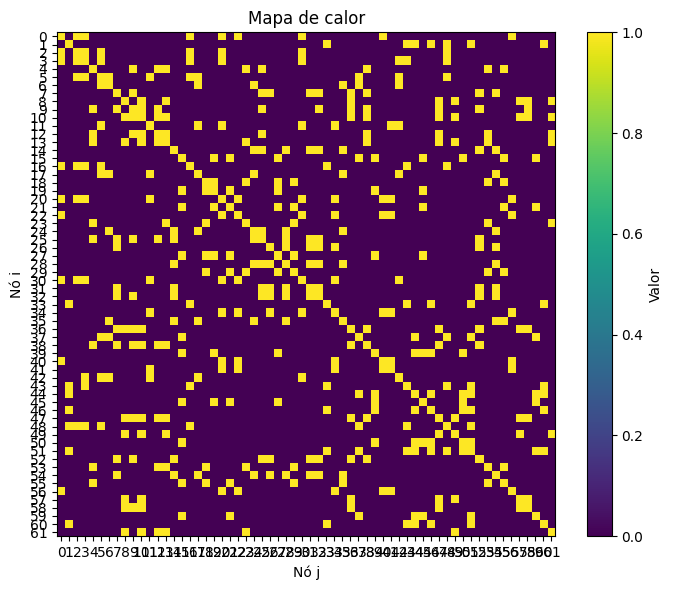

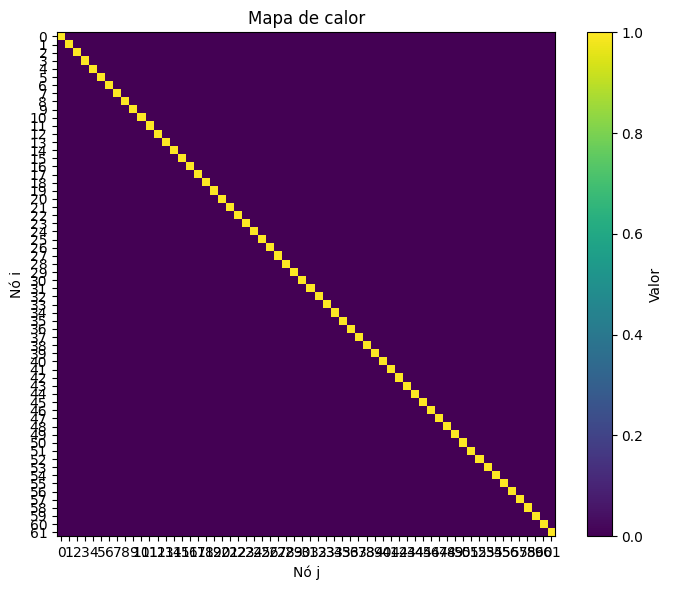

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [154]:
plot_heatmap_nn(torch.abs(adjacency_matrix(N, edge_index)))
plot_heatmap_nn(model.cell_0.A)

In [180]:
model.eval()
with torch.no_grad():
    pred  = model(X_test.to(device)).detach().cpu()
    pred_denormalized      = torch.expm1(pred * target_std + target_mean)
    y_test_denormalized    = torch.expm1(y_test * target_std + target_mean)

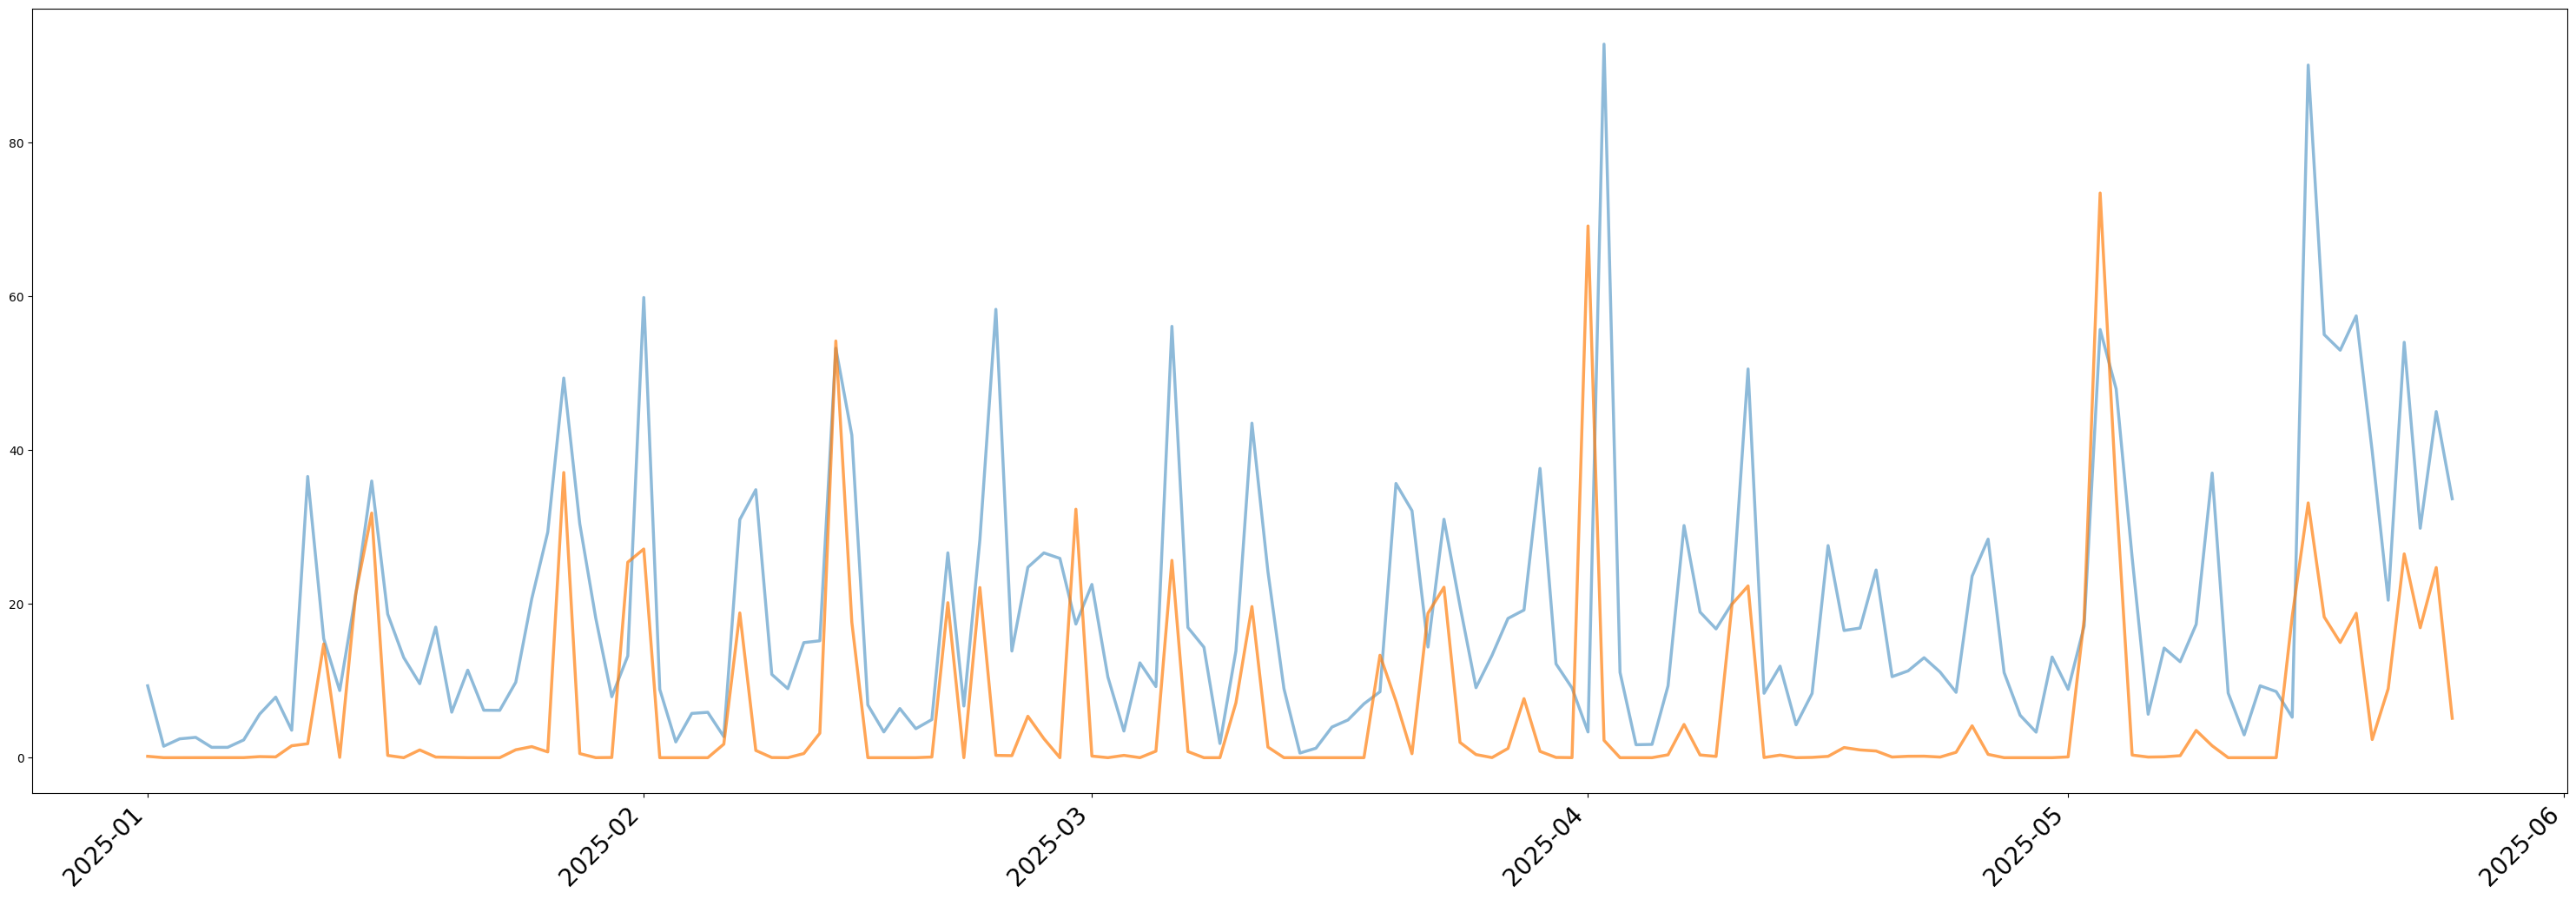

In [196]:
import matplotlib.dates as mdates
import seaborn as sns

from Evaluation.comparison_plots import _flatten_unique_days

plot_date = "2025-01-01"

len_ = slice(0, pred.shape[0])
vertex_idx = 55

dates = pd.date_range(start=plot_date, periods=pred_denormalized.shape[0], freq="D")

plt.figure(figsize=(30,10))
plt.xticks(fontsize=20, rotation=45, ha='right')
plt.tight_layout()
plt.plot(dates[len_], 3 * _flatten_unique_days(pred_denormalized, stride=1)[len_, vertex_idx], 
         lw=2.5,  alpha=0.50)
plt.plot(dates[len_], _flatten_unique_days(y_test_denormalized, stride=1)[len_, vertex_idx],
         lw=2.5, alpha=0.70)

# Imports necessários


In [150]:
def plot_estacao_unica(y_real, y_pred, station_idx, start_date_plot, station_name=None):
    """
    y_real, y_pred: tensores [T, N] (escala física, ex: mm/dia)
    station_idx: índice do nó/estação
    start_date_plot: ex. "2025-01-01"
    """
    y_real_np = y_real[..., station_idx].detach().cpu().numpy()
    y_pred_np = y_pred[..., station_idx].detach().cpu().numpy()
    datas = pd.date_range(start=start_date_plot, periods=len(y_real_np), freq="D")

    plt.figure(figsize=(12, 4))
    plt.plot(datas, y_real_np, label="ERA5 real", linewidth=2)
    plt.plot(datas, y_pred_np, label="Rede estimado", linewidth=2)
    plt.title(f"Real vs Previsto - nó {station_idx}" if station_name is None else f"Real vs Previsto - {station_name}")
    plt.xlabel("Data")
    plt.ylabel("Precipitação")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def _flatten_unique_days(y, stride=1):
    """
    Remove dias sobrepostos entre batches.
    Espera y com shape [batches, horizon, stations] (ou [batches, horizon]).
    Retorna serie unica no tempo, sem repeticao de dias.
    """
    if hasattr(y, "detach"):
        y = y.detach().cpu().numpy()
    else:
        y = np.asarray(y)

    if y.ndim == 2:
        y = y[:, :, None]  # [batches, horizon, 1]
        squeeze_back = True
    else:
        squeeze_back = False

    if y.ndim != 3:
        raise ValueError(f"y deve ter 2 ou 3 dimensoes. Recebido shape={y.shape}")

    batches, horizon, n_stations = y.shape
    if batches == 0:
        raise ValueError("y esta vazio.")
    if stride < 1:
        raise ValueError("stride deve ser >= 1.")

    if stride >= horizon:
        flat = y.reshape(batches * horizon, n_stations)
    else:
        parts = [y[0]]
        if batches > 1:
            tail = y[1:, -stride:, :].reshape(-1, n_stations)
            parts.append(tail)
        flat = np.concatenate(parts, axis=0)

    if squeeze_back:
        return flat[:, 0]
    return flat


def plot_precip_pred_vs_true(
    y_pred,
    y_true,
    station_idx=0,
    stride=1,
    start_date=None,
    station_name=None,
    ax=None,
    show=True,
    title=None,
):
    """
    Plota precipitacao predita vs real sem repetir dias.

    Parametros
    ----------
    y_pred, y_true : [batches, horizon, stations] (ou [batches, horizon])
        Exemplo: y_pred com shape [batchs, 5, 62].
    station_idx : int ou None
        Indice da estacao. Se None, plota a media das estacoes.
    stride : int
        Deslocamento entre batches. Para janelas deslizantes diarias, use 1.
    start_date : str ou None
        Data inicial (YYYY-MM-DD) para eixo x. Se None, usa indice.
    """
    y_pred_flat = _flatten_unique_days(y_pred, stride=stride)
    y_true_flat = _flatten_unique_days(y_true, stride=stride)

    if y_pred_flat.shape[0] != y_true_flat.shape[0]:
        raise ValueError(
            f"Tamanho temporal diferente: pred={y_pred_flat.shape[0]} vs true={y_true_flat.shape[0]}"
        )

    if y_pred_flat.ndim == 1:
        pred_series = y_pred_flat
        true_series = y_true_flat
        label = "serie"
    else:
        if station_idx is None:
            pred_series = y_pred_flat.mean(axis=1)
            true_series = y_true_flat.mean(axis=1)
            label = "media_estacoes"
        else:
            pred_series = y_pred_flat[:, station_idx]
            true_series = y_true_flat[:, station_idx]
            label = f"estacao {station_idx}" if station_name is None else station_name

    if start_date is not None:
        x = pd.date_range(start=start_date, periods=len(true_series), freq="D")
        xlabel = "Data"
    else:
        x = np.arange(len(true_series))
        xlabel = "Dia"

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    else:
        fig = ax.figure

    ax.plot(x, true_series, label="real", linewidth=2)
    ax.plot(x, pred_series, label="predito", linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Precipitacao")
    ax.set_title(title or f"Precipitacao real vs predita - {label}")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

def prever_futuro_precip_todos_nos(
    model,
    X_hist_ready,              # [T_hist, N, F] já no mesmo pré-processamento do treino
    horizon,                   # número de dias/passos futuros
    train_period,              # mesmo train_period usado no treino
    future_exog_ready=None,    # [horizon, N, F] (opcional). Se None, replica último passo
    target_col=0,              # coluna da precipitação nas features
    device=None,
    inverse_transformer=None,  # ex: pt_x (PowerTransformer), opcional
):
    """
    Retorna:
      pred_scaled: [horizon, N] na escala do modelo
      pred_real:   [horizon, N] em escala física (se inverse_transformer for fornecido), senão None
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    n_in = model.cell.W_i.in_features
    seq_len = train_period - 1

    if X_hist_ready.ndim != 3:
        raise ValueError("X_hist_ready deve ter shape [T_hist, N, F].")
    if X_hist_ready.shape[0] < seq_len:
        raise ValueError(f"Histórico insuficiente: precisa de pelo menos {seq_len} passos.")
    if future_exog_ready is not None and future_exog_ready.shape[0] < horizon:
        raise ValueError("future_exog_ready tem menos passos que horizon.")

    X_hist_ready = X_hist_ready[:, :, :n_in].float().cpu()
    if future_exog_ready is not None:
        future_exog_ready = future_exog_ready[:, :, :n_in].float().cpu()

    window = X_hist_ready[-seq_len:].clone()  # [seq_len, N, F]
    preds = []

    with torch.no_grad():
        for h in range(horizon):
            y_hat = model(window.unsqueeze(0).to(device)).squeeze(0).detach().cpu()  # [N]
            preds.append(y_hat)
            next_step = window[-1].clone() if future_exog_ready is None else future_exog_ready[h].clone()
            next_step[:, target_col] = y_hat  # autoregressivo
            window = torch.cat([window[1:], next_step.unsqueeze(0)], dim=0)

    pred_scaled = torch.sack(preds, dim=0)  # [horizon, N]

    pred_real = None
    if inverse_transformer is not None:
        arr = pred_scaled.numpy().reshape(-1, 1)
        inv = inverse_transformer.inverse_transform(arr).reshape(pred_scaled.shape)
        pred_real = torch.tensor(inv, dtype=torch.float32)

    return pred_scaled, pred_real


def eval_with_loader(model, loader, criterion, use_amp, amp_device, amp_dtype):
    model.eval()
    total_loss, total_mse, total_mae, total_mape, total_r2 = 0.0, 0.0, 0.0, 0.0, 0.0
    steps = 0
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()
    loss_fn = criterion if criterion is not None else nn.MSELoss()
    
    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            assert_finite(f"eval_xb_batch{batch_idx}", xb)
            assert_finite(f"eval_yb_batch{batch_idx}", yb)

            with torch.autocast(device_type=amp_device, dtype=amp_dtype, enabled=use_amp):
                pred = model(xb)
                assert_finite(f"eval_pred_batch{batch_idx}", pred)
                loss = loss_fn(pred, yb)

            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite eval loss on batch={batch_idx}")

            total_loss += loss.item()
            total_mse += mse_fn(pred, yb).item()
            total_mae += mae_fn(pred, yb).item()
            total_mape += safe_mape(yb, pred, eps=1e-3).item()
            total_r2 += safe_r2(yb.reshape(-1), pred.reshape(-1)).item()
            steps += 1

    return {
        "loss": total_loss / max(steps, 1),
        "mse": total_mse / max(steps, 1),
        "mae": total_mae / max(steps, 1),
        "mape": total_mape / max(steps, 1),
        "r2": total_r2 / max(steps, 1),
    }


def train_batched_only(model, train_loader, val_loader, train_period, hidden_dim, epochs, lr, weight_decay, patience, criterion=None, run_dir=None):
    model = copy.deepcopy(model).to(device)
    print(criterion)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()
    loss_fn = criterion if criterion is not None else nn.MSELoss()

    # Estável para debug: AMP desligado
    use_amp = False
    amp_device = "cuda"
    amp_dtype = torch.float16
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    print(f"train_batched_only: use_amp={use_amp}")

    best_model = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    counter = 0

    history = {
        "train_loss": [], "train_mse": [], "train_mae": [], "train_mape": [], "train_r2": [],
        "val_loss": [], "val_mse": [], "val_mae": [], "val_mape": [], "val_r2": [], "epoch_time": []
    }

    for ep in range(epochs):
        t0 = time.perf_counter()
        model.train()
        train_loss = 0.0
        train_mse = 0.0
        train_mae = 0.0
        train_mape = 0.0
        train_r2 = 0.0
        steps = 0

        for batch_idx, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            assert_finite(f"train_xb_epoch{ep}_batch{batch_idx}", xb)
            assert_finite(f"train_yb_epoch{ep}_batch{batch_idx}", yb)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=amp_device, dtype=amp_dtype, enabled=use_amp):
                pred = model(xb)
                assert_finite(f"train_pred_epoch{ep}_batch{batch_idx}", pred)
                loss = loss_fn(pred, yb)

            if not torch.isfinite(loss):
                raise RuntimeError(f"non-finite loss epoch={ep} batch={batch_idx}")

            scaler.scale(loss).backward()
            
            

            for name, param in model.named_parameters():
                #if param.grad is not None:
                    #print(name, param.grad.abs().mean())
                if param.grad is not None and (not torch.isfinite(param.grad).all()):
                    raise RuntimeError(f"non-finite gradient in {name} epoch={ep} batch={batch_idx}")

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.8)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_mse += mse_fn(pred, yb).item()
            train_mae += mae_fn(pred, yb).item()
            train_mape += safe_mape(yb, pred, eps=1e-3).item()
            train_r2 += safe_r2(yb.reshape(-1), pred.reshape(-1)).item()
            steps += 1

        history["train_loss"].append(train_loss / max(steps, 1))
        history["train_mse"].append(train_mse / max(steps, 1))
        history["train_mae"].append(train_mae / max(steps, 1))
        history["train_mape"].append(train_mape / max(steps, 1))
        history["train_r2"].append(train_r2 / max(steps, 1))

        val_metrics = eval_with_loader(model, val_loader, criterion=criterion, use_amp=use_amp, amp_device=amp_device, amp_dtype=amp_dtype)
        history["val_loss"].append(val_metrics["loss"])
        history["val_mse"].append(val_metrics["mse"])
        history["val_mae"].append(val_metrics["mae"])
        history["val_mape"].append(val_metrics["mape"])
        history["val_r2"].append(val_metrics["r2"])

        history["epoch_time"].append(time.perf_counter() - t0)

        print(
            f"epoch={ep+1}/{epochs}" 
            f"train_loss={history['train_loss'][-1]:e}/"
            f"val_loss={history['val_loss'][-1]:e}/"
            f"train_mae={history['train_mae'][-1]:e}/"
            f"val_mae={history['val_mae'][-1]:e}/" 
            f"val_mape={history['val_mape'][-1]:e}/"
            f"val_r2={history['val_r2'][-1]:e}"
        )

        if history["val_loss"][-1] < best_val_loss:
            best_val_loss = history["val_loss"][-1]
            counter = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            counter += 1

        if counter > patience:
            model.load_state_dict(best_model)
            print("Early Stopping")
            break

    model.load_state_dict(best_model)

    summary = {
        "hiddem_dim"        : hidden_dim,
        'train_period'      : train_period,
        "device"            : device,
        "epochs_requested"  : epochs,
        "epochs_ran"        : len(history["epoch_time"]),
        "lr"                : lr,
        "weight_decay"      : weight_decay,
        "patience"          : patience,
        "batch_size"        : train_loader.batch_size,
        "best_val_loss"     : best_val_loss,
        "last_val_mse"      : history["val_mse"][-1] if history["val_mse"] else None,
        "last_val_mae"      : history["val_mae"][-1] if history["val_mae"] else None,
        "last_val_mape"     : history["val_mape"][-1] if history["val_mape"] else None,
        "last_val_r2"       : history["val_r2"][-1] if history["val_r2"] else None,
        "total_time_s"      : float(sum(history["epoch_time"])),
    }

    if run_dir is not None:
        run_dir = Path(run_dir)
        run_dir.mkdir(parents=True, exist_ok=True)

        save_error_plots(
            str(run_dir),
            history["train_mse"], history["val_mse"],
            history["train_mae"], history["val_mae"],
            history["train_r2"],  history["val_r2"],
        )

        torch.save(history, run_dir / "hist.pt")
        torch.save(model.state_dict(), run_dir / "model_state_dict.pt")
        with open(run_dir / "run_summary.json", "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2)

    return model, history, summary


def weighted_mse_loss(
    y_pred,
    y_true,
    extreme_quantile=0.9,
    extreme_weight=10.0,
    is_log=True,
    eps=1e-6
):
    """
    Weighted MSE loss that emphasizes extreme rainfall, compatible with both
    log-transformed and raw targets.

    Args:
        y_pred: torch.Tensor, model predictions
        y_true: torch.Tensor, true values
        extreme_quantile: float, quantile to define "extreme rainfall" (default 0.9)
        extreme_weight: float, weight multiplier for extreme rainfall (default 5.0)
        is_log: bool, whether y_true (and y_pred) are log-transformed (default True)
        eps: small number to prevent log(0)
    """
    # Compute threshold in original scale
    if is_log:
        y_true_orig = torch.expm1(y_true)
        y_pred_orig = torch.expm1(y_pred)
    else:
        y_true_orig = y_true
        y_pred_orig = y_pred

    threshold = torch.quantile(y_true_orig, extreme_quantile)

    # Create weights: extreme rainfall gets high weight
    weights = torch.ones_like(y_true)
    weights[y_true_orig > threshold] = extreme_weight

    # Weighted MSE (compute on original scale if is_log)
    if is_log:
        # compute loss in log space (optional: can use pred vs true in log)
        loss = torch.mean(weights * (y_pred - y_true) ** 2)
    else:
        loss = torch.mean(weights * (y_pred - y_true) ** 2)

    return loss